# UCI Adult: CVaR vs Leximin reductions vs unconstrained baseline

This notebook compares three classifiers on the UCI Adult income dataset, using `sex` as the protected attribute:

1. **Baseline** — plain `LogisticRegression`.
2. **CVaRReduction (α = 0.5)** — minimize CVaR of group losses at α = 0.5.
3. **LeximinReduction** — lexicographic-minimum group-loss aggregation.

We report per-group test loss, the leximin vector, and CVaR_α, plus an accuracy / worst-group trade-off picture.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from cvar_leximin import CVaRReduction, LeximinReduction
from cvar_leximin.metrics import subgroup_cvar, subgroup_losses, leximin_vector
from cvar_leximin.fairlearn_compat import summary

rng = np.random.default_rng(0)

## Load UCI Adult

If network is unavailable, the cell below falls back to a small synthetic dataset so the notebook still runs end-to-end.

In [2]:
try:
    adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
    df = adult.frame.dropna().copy()
    y = (df['class'] == '>50K').astype(int).to_numpy()
    sensitive = df['sex'].astype(str).to_numpy()
    df = df.drop(columns=['class'])
    cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    pre = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    X = pre.fit_transform(df)
    source = 'uci-adult'
except Exception as e:
    print(f'fetch_openml failed ({e!r}); using synthetic fallback')
    n = 1500
    X = rng.normal(size=(n, 6))
    sensitive = rng.choice(['Male', 'Female'], size=n, p=[0.65, 0.35])
    noise = np.where(sensitive == 'Female', 1.2, 0.5)
    y = (X[:, 0] + X[:, 1] + rng.normal(0, noise) > 0).astype(int)
    source = 'synthetic-fallback'
print('source:', source, '| n =', len(y), '| groups:', np.unique(sensitive, return_counts=True))

source: uci-adult | n = 45222 | groups: (array(['Female', 'Male'], dtype=object), array([14695, 30527]))


In [3]:
X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=0, stratify=sensitive
)

## Fit three models

In [4]:
def base_est():
    return LogisticRegression(max_iter=500, solver='liblinear')

baseline = base_est().fit(X_tr, y_tr)
cvar = CVaRReduction(base_est(), alpha=0.5, max_iter=8, eta=1.0).fit(
    X_tr, y_tr, sensitive_features=s_tr
)
lex = LeximinReduction(base_est(), max_iter_per_level=5, eta=1.5).fit(
    X_tr, y_tr, sensitive_features=s_tr
)

preds = {
    'baseline': baseline.predict(X_te),
    'cvar-α=0.5': cvar.predict(X_te),
    'leximin': lex.predict(X_te),
}

In [5]:
rows = []
for name, p in preds.items():
    s = summary(y_te, p, s_te, alpha=0.5)
    losses = s['per_group_loss']
    rows.append({
        'model': name,
        'overall_accuracy': float((p == y_te).mean()),
        'worst_group_loss': max(losses.values()),
        'cvar_alpha_0.5': s['cvar_alpha'],
        **{f'loss[{g}]': v for g, v in losses.items()},
    })
report = pd.DataFrame(rows).set_index('model')
report

,overall_accuracy,worst_group_loss,cvar_alpha_0.5,loss[Female],loss[Male]
model,,,,,
baseline,0.847719,0.190325,0.190325,0.073259,0.190325
cvar-α=0.5,0.848161,0.189889,0.189889,0.072806,0.189889
leximin,0.847940,0.190216,0.190216,0.072806,0.190216


## Accuracy / worst-group trade-off curve

Sweep CVaR α from 1.0 (= mean) to 0.0 (= strict maximin).

In [6]:
try:
    import matplotlib.pyplot as plt
    have_plt = True
except ImportError:
    have_plt = False

alphas = [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]
sweep = []
for a in alphas:
    m = CVaRReduction(base_est(), alpha=a, max_iter=6, eta=1.0).fit(
        X_tr, y_tr, sensitive_features=s_tr
    )
    p = m.predict(X_te)
    losses = subgroup_losses(y_te, p, s_te)
    sweep.append({'alpha': a, 'accuracy': float((p == y_te).mean()),
                  'worst_group_loss': max(losses.values())})
sweep_df = pd.DataFrame(sweep)
sweep_df

,alpha,accuracy,worst_group_loss
0,1.0,0.847719,0.190325
1,0.7,0.847719,0.190325
2,0.5,0.848161,0.189889
3,0.3,0.848161,0.189889
4,0.1,0.848161,0.189889
5,0.0,0.848161,0.189889


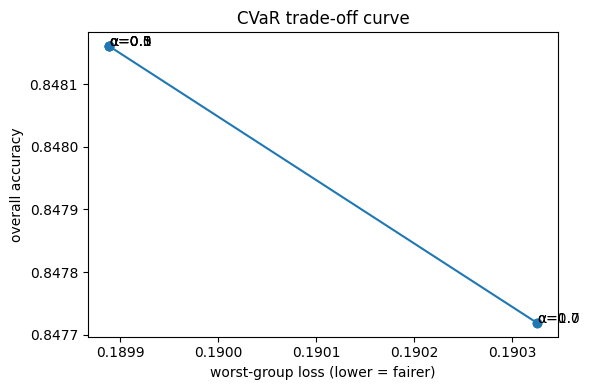

In [7]:
if have_plt:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sweep_df['worst_group_loss'], sweep_df['accuracy'], 'o-')
    for _, r in sweep_df.iterrows():
        ax.annotate(f"α={r['alpha']}", (r['worst_group_loss'], r['accuracy']))
    ax.set_xlabel('worst-group loss (lower = fairer)')
    ax.set_ylabel('overall accuracy')
    ax.set_title('CVaR trade-off curve')
    plt.tight_layout()
    plt.show()
else:
    print('matplotlib not installed; numerical trade-off shown above')

## Notes & caveats

- These reductions inherit the **resource-fetishism critique** of primary-goods framings (Sen, 1979). They equalize *loss* across protected groups, not capability. See README for the Sen acknowledgement.
- Training-set results are not a generalization guarantee. For deployment use held-out evaluation + bootstrap CIs (`cvar_leximin.metrics.bootstrap_ci`).
- This is **not** a compliance certification. Local regulations (EU AI Act, NYC LL144, etc.) define acceptable group-fairness targets; this library is an algorithmic tool, not legal advice.